In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Desktop\E2E-Fraud-Detection\notebooks\cleaned_data.csv")

In [2]:
df.shape

(6362620, 15)

In [3]:
df.sample(3)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,hour,day
4318278,308,PAYMENT,7743.01,C2087642691,0.0,0.0,M450341381,0.00,0.00,0,0,7743.01,7.743010e+03,20,12
2587870,207,CASH_OUT,256475.18,C896673153,0.0,0.0,C166977072,685196.24,941671.42,0,0,256475.18,-1.164153e-10,15,8
657785,35,PAYMENT,35572.68,C910423890,0.0,0.0,M1530380554,0.00,0.00,0,0,35572.68,3.557268e+04,11,1


In [4]:
feature_cols = ["type", "amount", "oldbalanceOrg", "newbalanceOrig",
                "oldbalanceDest", "newbalanceDest", "errorBalanceOrig",
                "errorBalanceDest", "hour", "day"]

In [5]:
X = pd.get_dummies(df[feature_cols], columns=["type"], drop_first=True)
X.head(3)

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,hour,day,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,1,0,False,False,True,False
1,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,1,0,False,False,True,False
2,181.00,181.0,0.00,0.0,0.0,0.0,181.00,1,0,False,False,False,True


In [6]:
y = df["isFraud"]

In [7]:
y.head(3)

0    0
1    0
2    1
Name: isFraud, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [10]:
X_train.shape

(5090096, 13)

In [11]:
X_test.shape

(1272524, 13)

In [12]:
y_train.mean()

np.float64(0.0012907418642005967)

In [13]:
y_test.mean()

np.float64(0.0012911347840983745)

In [14]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

In [15]:
scale_pos_weight

np.float64(773.7482496194825)

In [16]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced",
    n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("PR-AUC :", average_precision_score(y_test, rf_proba))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9850    0.9976    0.9912      1643

    accuracy                         1.0000   1272524
   macro avg     0.9925    0.9988    0.9956   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

ROC-AUC: 0.9996956831863235
PR-AUC : 0.9987165630229685


In [17]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,

    scale_pos_weight=scale_pos_weight,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,
    gamma=0.1,

    tree_method="hist",

    eval_metric="aucpr",
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print("PR-AUC :", average_precision_score(y_test, xgb_proba))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9964    0.9976    0.9970      1643

    accuracy                         1.0000   1272524
   macro avg     0.9982    0.9988    0.9985   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

ROC-AUC: 0.9995305799730226
PR-AUC : 0.9983552551840829


In [18]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,

    auto_class_weights="Balanced",

    eval_metric="PRAUC",
    random_state=42,

    loss_function="Logloss",

    verbose=False
)
cat.fit(X_train, y_train)
cat_proba = cat.predict_proba(X_test)[:, 1]
cat_pred = cat.predict(X_test)

print(classification_report(y_test, cat_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, cat_proba))
print("PR-AUC :", average_precision_score(y_test, cat_proba))

              precision    recall  f1-score   support

           0     1.0000    0.9999    1.0000   1270881
           1     0.9596    0.9982    0.9785      1643

    accuracy                         0.9999   1272524
   macro avg     0.9798    0.9991    0.9892   1272524
weighted avg     0.9999    0.9999    0.9999   1272524

ROC-AUC: 0.9997192850269823
PR-AUC : 0.9986775939050925


In [19]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "XGBoost": (xgb_pred, xgb_proba),
    "CatBoost": (cat_pred, cat_proba),
}

In [21]:
rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "model": name,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    })

In [22]:
comparison = pd.DataFrame(rows).set_index("model").round(4)
comparison

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.9850,0.9976,0.9912,0.9997,0.9987
XGBoost,0.9964,0.9976,0.9970,0.9995,0.9984
CatBoost,0.9596,0.9982,0.9785,0.9997,0.9987


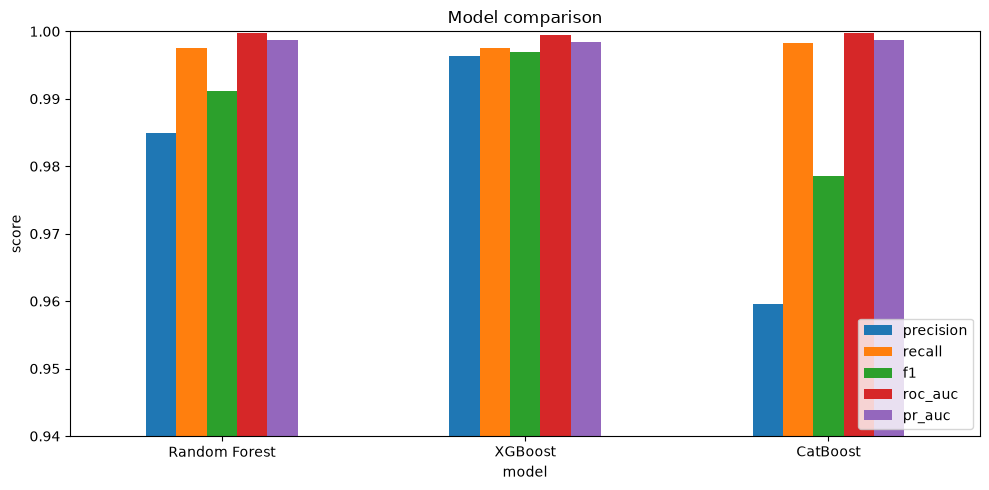

In [24]:
import matplotlib.pyplot as plt

comparison.plot(kind="bar", figsize=(10, 5), ylim=(0.94, 1.0))
plt.title("Model comparison")
plt.ylabel("score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [25]:
X_train.columns

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'hour', 'day',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='str')

In [26]:
len(X_train.columns)

13

In [27]:
import joblib
import json
from datetime import datetime

joblib.dump(xgb, "xgb_fraud_model.joblib")


['xgb_fraud_model.joblib']

In [28]:
joblib.dump(list(X_train.columns), "xgb_feature_columns.joblib")

['xgb_feature_columns.joblib']

In [29]:
metadata = {
    "model_type": "XGBClassifier",
    "trained_at": datetime.now().isoformat(),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "fraud_rate_train": float(y_train.mean()),
    "params": xgb.get_params(),
    "metrics": {
        "precision": float(precision_score(y_test, xgb_pred)),
        "recall": float(recall_score(y_test, xgb_pred)),
        "f1": float(f1_score(y_test, xgb_pred)),
        "roc_auc": float(roc_auc_score(y_test, xgb_proba)),
        "pr_auc": float(average_precision_score(y_test, xgb_proba)),
    },
}
with open("xgb_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)